In [ ]:
from entregable_tfg_chatbot.etl import load_csv, filter_rows, select_columns, remove_incorrect_cataloged_rows, get_images_json_to_list, get_one_image_of_list,copy_images_to_folder
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import shutil
import os

In [3]:
 # Load the CSV file
df = load_csv('../data/store_zara_data/store_zara.csv')

In [4]:
# Filter and select columns
df_row_filtered = filter_rows(df, "terms =='shoes'")

In [5]:
# Select relevant columns
df_cols_selected = select_columns(df_row_filtered, ['name','description','price','currency','section','terms','image_downloads'])

In [6]:
# Filter rows with section == MAN
df_man = filter_rows(df_cols_selected, "section =='MAN'").reset_index(drop=True)

In [7]:
 # Remove incorrect cataloged rows in df_woman
df_man_removed_rows = remove_incorrect_cataloged_rows(df_man, [142])

In [8]:
# convert json to list in image_downloads
df_man_removed_rows.loc[:,'image_downloads']= df_man_removed_rows['image_downloads'].apply(get_images_json_to_list)

In [9]:
# Get one image of list
df_man_one_image = get_one_image_of_list(df_man_removed_rows, 11, 2, -3)

In [10]:
# Select final columns
df_man_final_cols= select_columns(df_man_one_image, ['name','description','price','currency','iso_image'])
df_man_final_cols.head(3)

,name,description,price,currency,iso_image
0,CHUNKY SOLE CHELSEA BOOTS,Chelsea boots. Shaft with elastic goring on bo...,59.9,USD,30d15b5c-bb33-4804-9c90-59b884a9be63
1,CHUNKY SOLE SNEAKERS,Sneakers. Upper in a combination of materials ...,49.9,USD,a6e76df6-a31d-46f4-b44f-9c0118bf098b
2,SQUARED TOE LEATHER BOOTS,Leather ankle boots. Square shaped. Side zippe...,159.0,USD,435cc093-08b5-48e0-91ba-cfce112d4105


In [11]:
def create_folder(path):
    return os.mkdir(path)

In [12]:
image_folder_path = "../data/men_images"
create_folder(image_folder_path)

### Copiar imagenes definitivas calzado hombre al directorio final  'men_images'

In [13]:
path = "../data/store_zara_data/images/zara/"
column = 'iso_image'
copy_images_to_folder(df_man_final_cols, column, path, image_folder_path)

# 

## Guardar descipciones producto calzado hombre en txt.

In [14]:
def create_txt_files(df: pd.DataFrame, destination_dir: str):
    for row in df.iterrows():
        name = 'Name: ' + row[1]['name'] + '\n'
        descripcion = 'Description: ' + row[1]['description'] + '\n'
        price = 'Price: ' + str(row[1]['price']) + '\n'
        currency = 'Currency: ' + str(row[1]['currency']) 
        images_reference = row[1]['iso_image']
        with open('../data/men_txt/'+ images_reference + '.txt', 'w') as f:
            f.write(name) 
            f.write(descripcion)
            f.write(price)
            f.write(currency)

In [15]:
txt_folder_path = "../data/men_txt"
create_folder(txt_folder_path)

In [16]:
create_txt_files(df_man_final_cols, txt_folder_path)

## Guardar csv file definitvo calzado hombre.

In [17]:
# Save dataframe final 
df_man_final_cols.to_csv('../data/shoes_man_etl.csv', index=False)

#### Mostrar galería de imágenes de producto calzado hombre final 

In [18]:
def show_images12x13(lista_imagenes):
    """ Funcion para mostrar las imagenes"""
    fig, axs = plt.subplots(nrows=12, ncols=13, figsize=(20,15))
    for i in range(12):
        for j in range(13):
            if i * 13 + j < len(lista_imagenes):
                image_path = "../data/store_zara_data/images/zara/" + str(lista_imagenes[i * 13 + j]) + ".jpg"
                image = Image.open(image_path).convert("RGB")
                axs[i, j].imshow(image)
                axs[i, j].axis('off')
    plt.tight_layout()
    plt.show()
    return fig

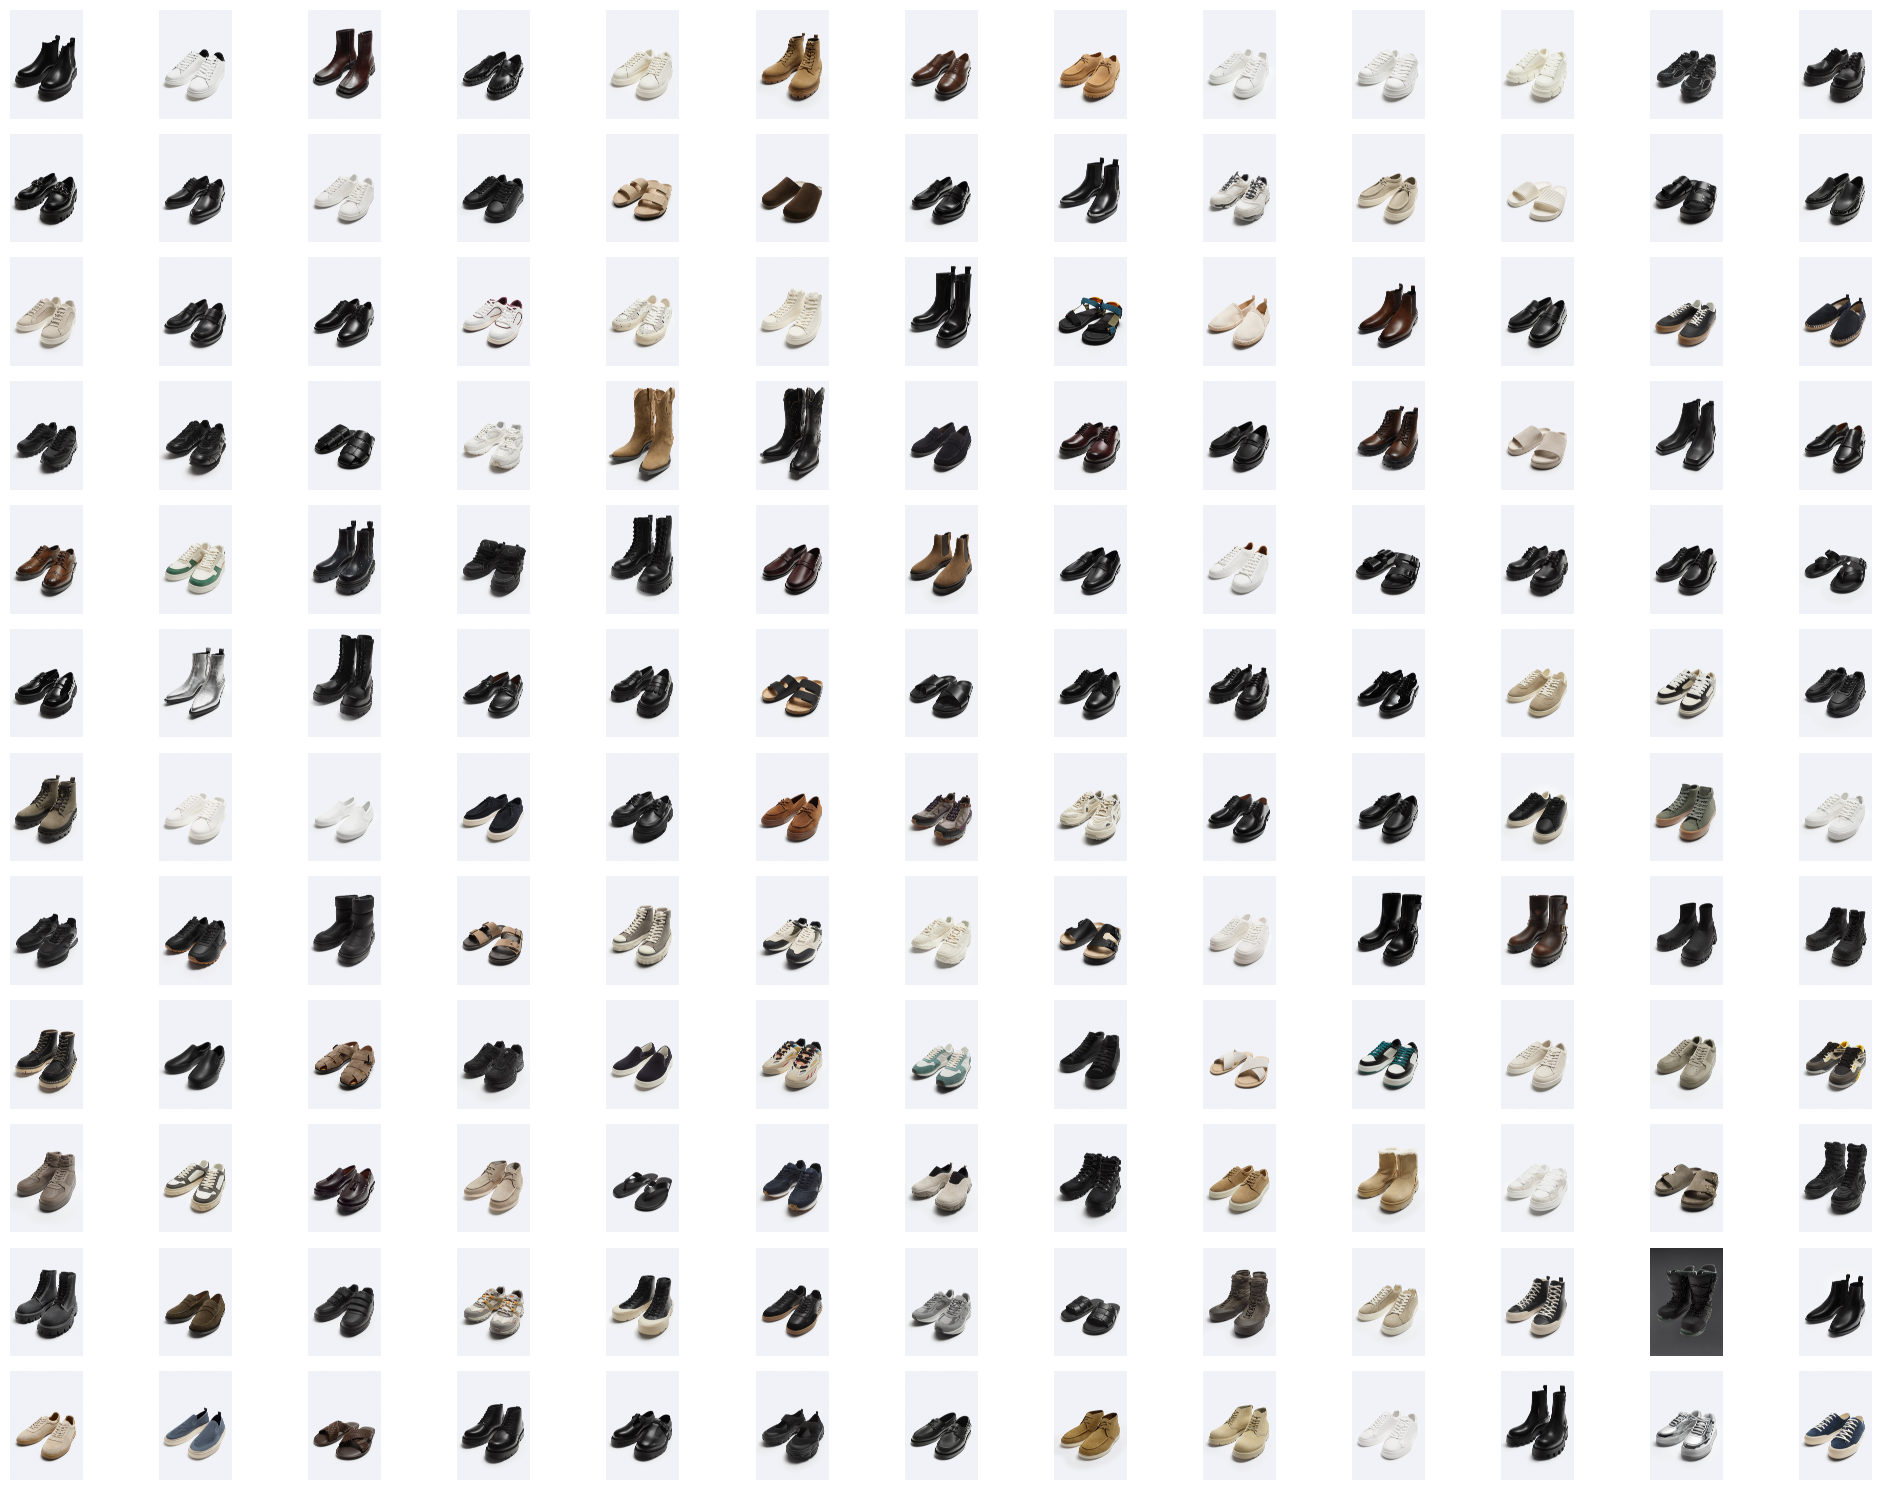

In [19]:
total_iso_images_men =df_man_final_cols['iso_image'].to_list()
fig = show_images12x13(total_iso_images_men)


In [20]:
# Exportar la figura a un archivo JPG
fig.savefig('../data/men_shoes_output.jpg', dpi=300)